<a href="https://colab.research.google.com/github/Lea17-hub/camera-optics-lab/blob/main/01_ideal_psf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Ideal Diffraction-Limited PSF

## Question

Why does a point source not remain a perfect point after passing through an optical system?

In this notebook, we model a circular aperture and calculate the corresponding diffraction-limited point spread function (PSF).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

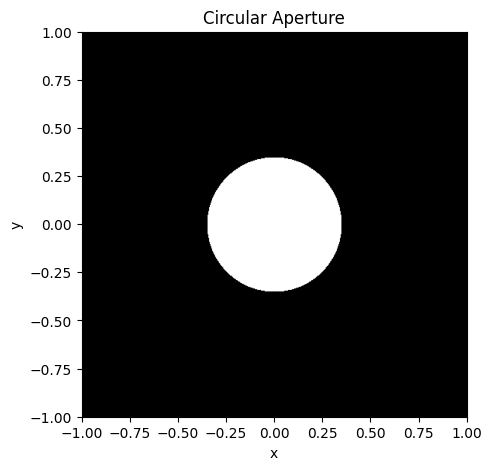

In [3]:
# Grid size
N = 512

# Coordinate range
x = np.linspace(-1, 1, N)
y = np.linspace(-1, 1, N)

X, Y = np.meshgrid(x, y)

# Radial distance from the center
R = np.sqrt(X**2 + Y**2)

# Circular aperture radius
radius = 0.35

# Aperture: 1 inside the circle, 0 outside
aperture = (R <= radius).astype(float)

plt.figure(figsize=(5, 5))
plt.imshow(aperture, cmap="gray", extent=[-1, 1, -1, 1])
plt.title("Circular Aperture")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

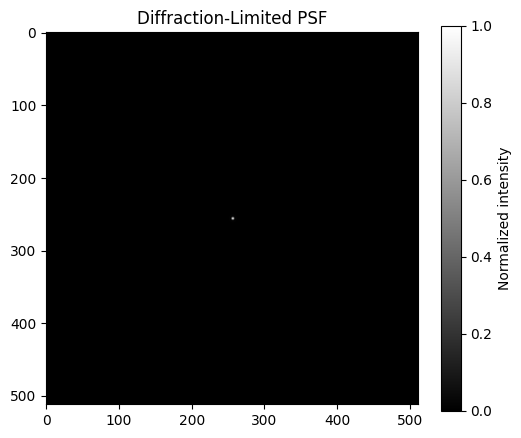

In [4]:
# Fourier transform of the aperture
field = np.fft.fftshift(np.fft.fft2(aperture))

# Intensity = |field|^2
intensity = np.abs(field)**2

# Normalize
psf = intensity / intensity.max()

plt.figure(figsize=(6, 5))
plt.imshow(psf, cmap="gray")
plt.title("Diffraction-Limited PSF")
plt.colorbar(label="Normalized intensity")
plt.show()

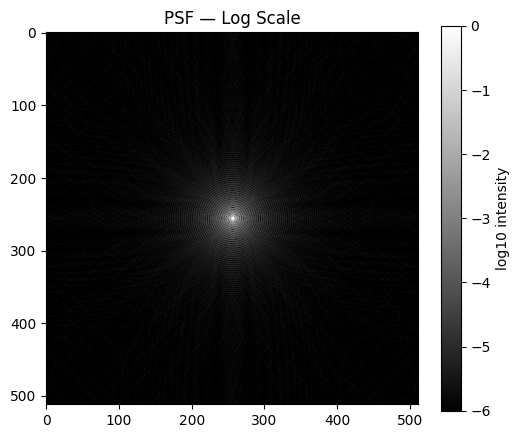

In [5]:
plt.figure(figsize=(6, 5))
plt.imshow(np.log10(psf + 1e-6), cmap="gray")
plt.title("PSF — Log Scale")
plt.colorbar(label="log10 intensity")
plt.show()

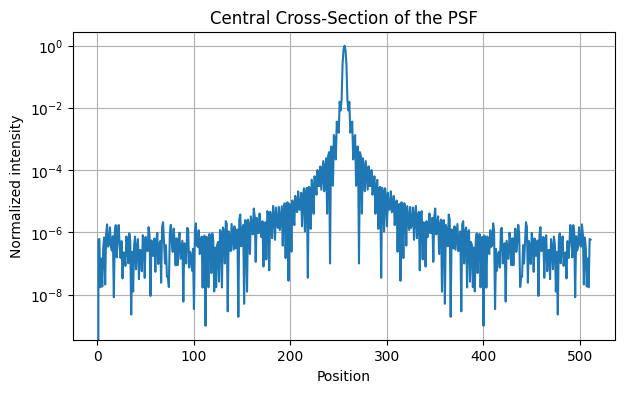

In [6]:
center = N // 2

profile = psf[center, :]

plt.figure(figsize=(7, 4))
plt.plot(profile)
plt.title("Central Cross-Section of the PSF")
plt.xlabel("Position")
plt.ylabel("Normalized intensity")
plt.yscale("log")
plt.grid(True)
plt.show()

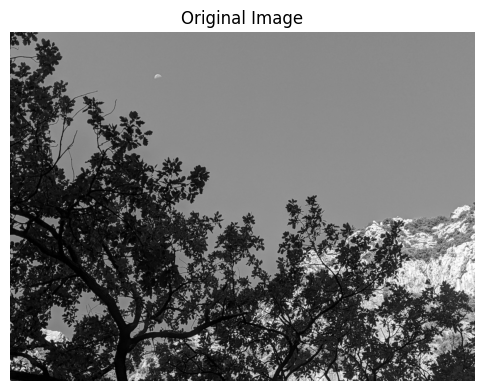

In [9]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("1000052418.jpg").convert("L")
img = np.array(img) / 255.0

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [10]:
from scipy.signal import fftconvolve

center = N // 2

crop = 41
half = crop // 2

psf_small = psf[
    center-half:center+half+1,
    center-half:center+half+1
]

psf_small = psf_small / psf_small.sum()

blurred = fftconvolve(img, psf_small, mode="same")

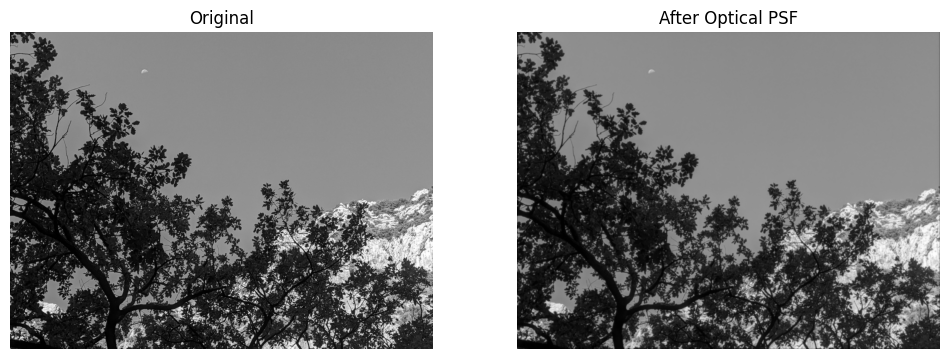

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred, cmap="gray")
plt.title("After Optical PSF")
plt.axis("off")

plt.show()

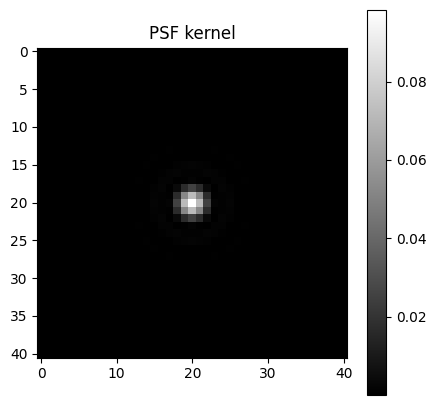

In [12]:
plt.figure(figsize=(5,5))
plt.imshow(psf_small, cmap="gray")
plt.title("PSF kernel")
plt.colorbar()
plt.show()

In [13]:
def make_psf(radius, N=512):
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, y)

    R = np.sqrt(X**2 + Y**2)

    aperture = (R <= radius).astype(float)

    field = np.fft.fftshift(np.fft.fft2(aperture))
    intensity = np.abs(field)**2

    psf = intensity / intensity.max()

    return aperture, psf

In [14]:
aperture_large, psf_large = make_psf(radius=0.35)
aperture_small, psf_small_ap = make_psf(radius=0.08)

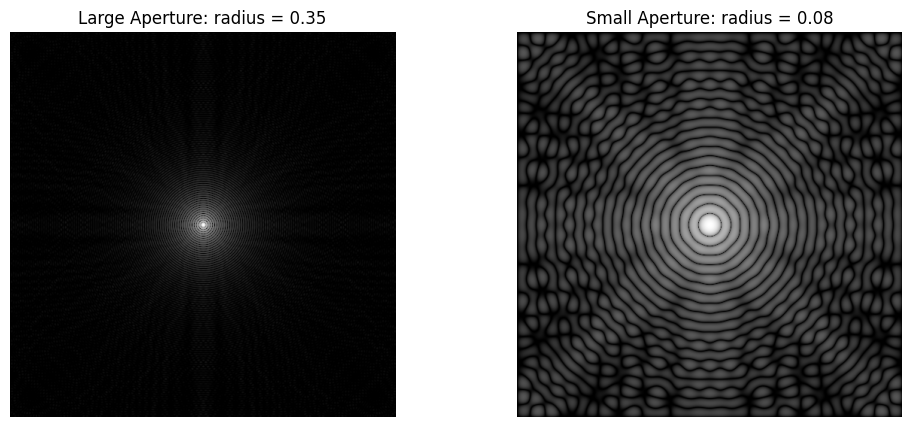

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.log10(psf_large + 1e-6), cmap="gray")
plt.title("Large Aperture: radius = 0.35")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.log10(psf_small_ap + 1e-6), cmap="gray")
plt.title("Small Aperture: radius = 0.08")
plt.axis("off")

plt.show()

In [16]:
from scipy.signal import fftconvolve

def blur_with_psf(img, psf, crop=81):
    center = psf.shape[0] // 2
    half = crop // 2

    kernel = psf[
        center-half:center+half+1,
        center-half:center+half+1
    ]

    kernel = kernel / kernel.sum()

    blurred = fftconvolve(img, kernel, mode="same")

    return blurred

In [17]:
blur_large = blur_with_psf(img, psf_large)
blur_small = blur_with_psf(img, psf_small_ap)

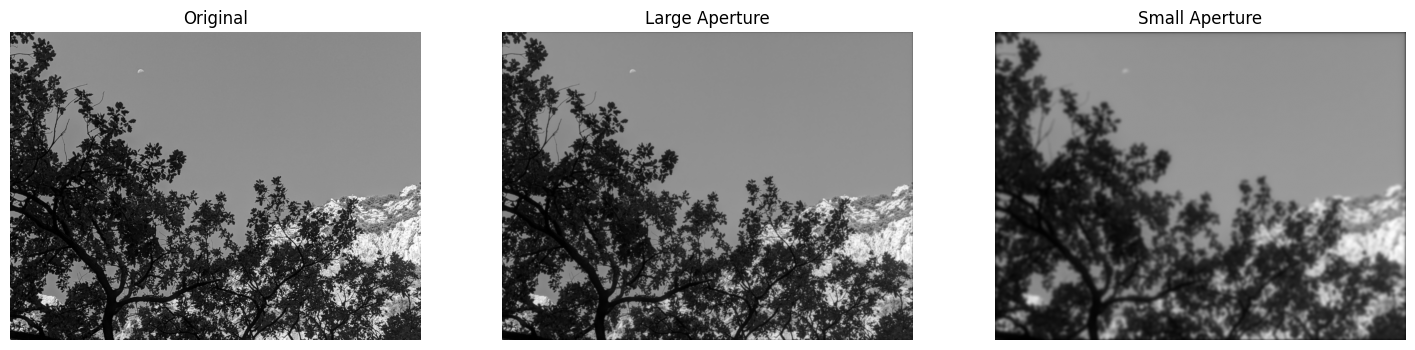

In [19]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blur_large, cmap="gray")
plt.title("Large Aperture")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blur_small, cmap="gray")
plt.title("Small Aperture")
plt.axis("off")

plt.savefig("figures/aperture_blur_comparison.png",
            dpi=300,
            bbox_inches="tight")
plt.show()